# Preparación vectorial y ponderación AHP del Índice de Potencial de Aguas Subterráneas (GWPI)

**Acuífero Raigón, San José — Uruguay**

Juan Nahuel Lamas · Grupo de Investigaciones Espaciales (GIEx), UTEC
Licenciado en Ciencias Geológicas (FCEN-UBA) · Maestrando en Geociencias (UdelaR–PEDECIBA)

---

## Qué hace este notebook

En el flujo publicado en esta carpeta, la integración multicriterio del GWPI se resolvió en **ArcGIS Pro con
ModelBuilder** (ver `resultados/01_modelbuilder_flujo-GPWI.png`) y los scripts de `scripts/` reproducen la parte
ráster: cálculo de pesos por autovector y suma ponderada.

Este notebook cubre **la etapa vectorial previa**, que en el proyecto original se ejecutó de forma interactiva
dentro del SIG y por lo tanto no quedaba documentada de manera reproducible. Reescribirla en Python tiene un
propósito concreto: que cualquiera pueda auditar y volver a correr las decisiones que definen los ratings de
entrada, que es donde realmente se juega el resultado de un análisis multicriterio.

Se resuelven aquí:

| Paso | Operación | Herramienta |
|---|---|---|
| 1 | Manejo de sistemas de referencia (SIRGAS-ROU98 geográfico → UTM 21S) | `pyproj`, `geopandas` |
| 2 | Construcción de la malla de análisis de 1 km | `shapely`, `geopandas` |
| 3 | Densidad de drenaje por celda | `geopandas.overlay` |
| 4 | Distancia a cursos de agua | `geopandas.sjoin_nearest` |
| 5 | Unidad geológica dominante por celda (ponderada por área) | `geopandas.overlay` + `groupby` |
| 6 | Estadística zonal de pendiente y TWI | `rasterio.features.rasterize` + `numpy.bincount` |
| 7 | Reclasificación 1–5 por cortes naturales de Jenks | `mapclassify` |
| 8 | Pesos AHP por autovector y razón de consistencia | `numpy` |
| 9 | Integración del GWPI y exportación a GeoPackage y GeoTIFF | `geopandas`, `rasterio` |
| 10 | Validación contra caudales específicos de pozos | `scipy.stats` |

## Sobre los datos

> **Nota importante.** Este notebook **no distribuye las capas originales del proyecto**: la geología
> 1:100.000, la red de drenaje de DINAGUA y los datos de pozos están sujetos a las condiciones de uso de
> las instituciones que los proveyeron, y el informe del proyecto está en proceso de publicación.
>
> Para que el notebook sea **ejecutable por cualquiera**, si no encuentra las capas reales en `datos/`
> genera un conjunto sintético reproducible (semilla fija) sobre la envolvente aproximada del acuífero, con
> la misma estructura de atributos y las mismas unidades geológicas del caso real. **Los números que produce
> esta corrida son, por lo tanto, demostrativos: sirven para auditar el código, no para citar resultados.**
> Los resultados publicados del proyecto provienen de las capas reales y están en `resultados/`.
>
> Si se colocan los archivos reales en `datos/` con los nombres indicados en la celda de carga, el notebook
> los usa sin ningún otro cambio.

## 0. Entorno

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import geopandas as gpd
import mapclassify
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import shapely
from rasterio.features import rasterize
from rasterio.transform import from_origin
from scipy import stats
from shapely.geometry import LineString, Point, box
from shapely.ops import voronoi_diagram

warnings.filterwarnings("ignore", category=RuntimeWarning)

print(f"geopandas   {gpd.__version__}")
print(f"shapely     {shapely.__version__}")
print(f"rasterio    {rasterio.__version__}")
print(f"mapclassify {mapclassify.__version__}")
print(f"pandas      {pd.__version__}")
print(f"numpy       {np.__version__}")

geopandas   1.1.4
shapely     2.1.2
rasterio    1.4.4
mapclassify 2.10.0
pandas      3.0.2
numpy       2.4.4


In [2]:
# ── Configuración del proyecto ────────────────────────────────────────────────
CRS_GEO = "EPSG:5381"   # SIRGAS-ROU98 (geográficas 2D) — CRS oficial del Uruguay
CRS_PRJ = "EPSG:5382"   # SIRGAS-ROU98 / UTM zona 21S   — CRS métrico de trabajo

CELDA_M = 1000          # lado de la celda de análisis, en metros
RES_M   = 30            # resolución de los rásteres continuos, en metros
SEMILLA = 20250903      # semilla para la generación sintética reproducible

DIR_DATOS  = Path("datos")
DIR_SALIDA = Path("salidas")
DIR_SALIDA.mkdir(exist_ok=True)

rng = np.random.default_rng(SEMILLA)

# Envolvente aproximada del área de estudio (San José, Uruguay), en grados
BBOX_GEO = (-57.05, -34.55, -56.45, -34.15)  # (oeste, sur, este, norte)

## 1. Sistemas de referencia

Uruguay adoptó **SIRGAS-ROU98** como marco geodésico oficial. En el territorio conviven dos husos UTM
(21S al oeste del meridiano 54°O y 22S al este), y el acuífero Raigón cae íntegramente en el **huso 21S**.

Toda operación métrica —longitudes, áreas, distancias, buffers— se hace en el CRS proyectado. Es un error
frecuente y silencioso calcular distancias sobre coordenadas geográficas: no falla, simplemente devuelve
grados decimales interpretados como metros. La celda siguiente cuantifica ese error para dejarlo explícito.

In [3]:
from pyproj import CRS

for codigo in ("EPSG:5381", "EPSG:5382", "EPSG:5383"):
    crs = CRS.from_user_input(codigo)
    print(f"{codigo}  {crs.name:35s}  unidades: {crs.axis_info[0].unit_name}")

EPSG:5381  SIRGAS-ROU98                         unidades: degree
EPSG:5382  SIRGAS-ROU98 / UTM zone 21S          unidades: metre
EPSG:5383  SIRGAS-ROU98 / UTM zone 22S          unidades: metre


In [4]:
# Área de estudio como GeoDataFrame, y demostración del efecto del CRS
aoi_geo = gpd.GeoDataFrame(
    {"nombre": ["Acuífero Raigón (envolvente aproximada)"]},
    geometry=[box(*BBOX_GEO)],
    crs=CRS_GEO,
)
aoi = aoi_geo.to_crs(CRS_PRJ)

area_mal = aoi_geo.geometry.area.iloc[0]                 # grados² — sin sentido físico
area_bien = aoi.geometry.area.iloc[0] / 1e6              # km²

print(f"Área calculada en {CRS_GEO} : {area_mal:>12.4f}  (grados cuadrados — no interpretable)")
print(f"Área calculada en {CRS_PRJ} : {area_bien:>12.1f}  km²")
print(f"\nExtensión proyectada (m): {[round(v) for v in aoi.total_bounds]}")

Área calculada en EPSG:5381 :       0.2400  (grados cuadrados — no interpretable)
Área calculada en EPSG:5382 :       2447.5  km²

Extensión proyectada (m): [495391, 6176721, 550702, 6221211]


/tmp/ipykernel_1781/4197268323.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area_mal = aoi_geo.geometry.area.iloc[0]                 # grados² — sin sentido físico


## 2. Capas de entrada

La función `cargar_o_simular` busca primero los archivos reales. Si no están, construye un conjunto
sintético con la misma estructura de atributos. Las unidades geológicas y sus calificaciones de
comportamiento hidráulico son las del caso real, tomadas de la carta geológica 1:100.000.

In [5]:
# Calificación hidrogeológica de las unidades (1 = pobre, 5 = muy favorable).
# Criterio: conductividad hidráulica y comportamiento documentado de cada unidad.
RATING_GEOLOGIA = {
    "Formación Raigón":       5,   # arenas y gravas — acuífero principal
    "Depósitos aluviales":    4,   # sedimentos actuales, buena permeabilidad
    "Formación Fray Bentos":  3,   # loess cementado, permeabilidad media a baja
    "Formación Libertad":     2,   # limos arcillosos, baja permeabilidad
    "Basamento cristalino":   1,   # permeabilidad sólo por fracturación
}
UNIDADES = list(RATING_GEOLOGIA)


def _red_drenaje_sintetica(bounds, n_troncos=9, rng=rng):
    """Genera una red de drenaje dendrítica simple dentro de la envolvente dada."""
    x0, y0, x1, y1 = bounds
    lineas, ordenes = [], []
    for _ in range(n_troncos):
        n = rng.integers(6, 12)
        xs = np.sort(rng.uniform(x0, x1, n))
        ys = np.linspace(rng.uniform(y0, y1), rng.uniform(y0, y1), n)
        ys = ys + rng.normal(0, (y1 - y0) * 0.035, n)   # sinuosidad
        tronco = LineString(np.column_stack([xs, ys]))
        lineas.append(tronco); ordenes.append(int(rng.integers(3, 5)))
        for _ in range(rng.integers(2, 5)):             # afluentes
            t = rng.uniform(0.15, 0.85)
            p = tronco.interpolate(t, normalized=True)
            ang = rng.uniform(0, 2 * np.pi)
            largo = rng.uniform(0.06, 0.20) * (x1 - x0)
            q = Point(p.x + largo * np.cos(ang), p.y + largo * np.sin(ang))
            lineas.append(LineString([p, q])); ordenes.append(int(rng.integers(1, 3)))
    return gpd.GeoDataFrame({"orden": ordenes}, geometry=lineas, crs=CRS_PRJ)


def _geologia_sintetica(aoi_geom, n=26, rng=rng):
    """Teselado de Voronoi sobre semillas aleatorias, recortado al área de estudio."""
    x0, y0, x1, y1 = aoi_geom.bounds
    semillas = shapely.MultiPoint(
        [Point(rng.uniform(x0, x1), rng.uniform(y0, y1)) for _ in range(n)]
    )
    celdas = list(voronoi_diagram(semillas, envelope=aoi_geom).geoms)
    # La Fm. Raigón es la unidad dominante del área; el basamento es marginal
    probs = np.array([0.34, 0.14, 0.20, 0.24, 0.08])
    unidades = rng.choice(UNIDADES, size=len(celdas), p=probs)
    g = gpd.GeoDataFrame({"unidad": unidades}, geometry=celdas, crs=CRS_PRJ)
    g["geometry"] = g.geometry.intersection(aoi_geom)
    g = g[~g.geometry.is_empty & g.geometry.notna()].copy()
    return g.dissolve(by="unidad", as_index=False)


def _campo_suave(shape, escala, rng=rng):
    """Campo aleatorio espacialmente autocorrelacionado (suavizado gaussiano por FFT)."""
    ruido = rng.normal(size=shape)
    ky = np.fft.fftfreq(shape[0])[:, None]
    kx = np.fft.fftfreq(shape[1])[None, :]
    filtro = np.exp(-((kx**2 + ky**2) * escala**2))
    campo = np.real(np.fft.ifft2(np.fft.fft2(ruido) * filtro))
    return (campo - campo.min()) / (campo.max() - campo.min())

In [6]:
def cargar_o_simular():
    """Carga las capas reales si existen; si no, genera el conjunto sintético."""
    f_dren, f_geol, f_pozos = (DIR_DATOS / n for n in
                               ("drenaje.gpkg", "geologia.gpkg", "pozos.gpkg"))
    if f_dren.exists() and f_geol.exists():
        print(">> Usando las capas reales de datos/")
        dren = gpd.read_file(f_dren).to_crs(CRS_PRJ)
        geol = gpd.read_file(f_geol).to_crs(CRS_PRJ)
        pozos = gpd.read_file(f_pozos).to_crs(CRS_PRJ) if f_pozos.exists() else None
        return dren, geol, pozos, False

    print(">> Capas reales no encontradas: generando conjunto sintético reproducible")
    print(f"   (semilla = {SEMILLA})")
    geom = aoi.geometry.iloc[0]
    dren = _red_drenaje_sintetica(geom.bounds)
    dren["geometry"] = dren.geometry.intersection(geom)
    dren = dren[~dren.geometry.is_empty & dren.geometry.notna()].copy()
    geol = _geologia_sintetica(geom)
    x0, y0, x1, y1 = geom.bounds
    pozos = gpd.GeoDataFrame(
        {"caudal_esp": np.round(rng.gamma(2.0, 1.4, 60), 2)},   # m³/h/m
        geometry=[Point(rng.uniform(x0, x1), rng.uniform(y0, y1)) for _ in range(60)],
        crs=CRS_PRJ,
    )
    return dren, geol, pozos, True


drenaje, geologia, pozos, SINTETICO = cargar_o_simular()

print(f"\ndrenaje  : {len(drenaje):4d} tramos   | longitud total {drenaje.length.sum()/1000:8.1f} km")
print(f"geologia : {len(geologia):4d} unidades | área total     {geologia.area.sum()/1e6:8.1f} km²")
print(f"pozos    : {len(pozos):4d} registros")
geologia[["unidad"]].assign(area_km2=(geologia.area / 1e6).round(1))

>> Capas reales no encontradas: generando conjunto sintético reproducible
   (semilla = 20250903)

drenaje  :   33 tramos   | longitud total    646.7 km
geologia :    5 unidades | área total       2447.5 km²
pozos    :   60 registros


,unidad,area_km2
0,Basamento cristalino,160.0
1,Depósitos aluviales,173.2
2,Formación Fray Bentos,110.8
3,Formación Libertad,1109.3
4,Formación Raigón,894.2


In [7]:
# Rásteres continuos: pendiente (%) y Topographic Wetness Index
x0, y0, x1, y1 = aoi.total_bounds
ancho  = int(np.ceil((x1 - x0) / RES_M))
alto   = int(np.ceil((y1 - y0) / RES_M))
transform = from_origin(x0, y1, RES_M, RES_M)

f_pend, f_twi = DIR_DATOS / "pendiente.tif", DIR_DATOS / "twi.tif"
if f_pend.exists() and f_twi.exists():
    print(">> Usando los rásteres reales de datos/")
    with rasterio.open(f_pend) as src: pendiente = src.read(1); transform = src.transform
    with rasterio.open(f_twi)  as src: twi = src.read(1)
else:
    # La longitud de autocorrelación se fija por encima del tamaño de celda (1 km),
    # para que la agregación zonal conserve estructura espacial y no promedie ruido.
    pendiente = _campo_suave((alto, ancho), escala=320) * 11.0          # 0–11 %
    twi       = 4.0 + _campo_suave((alto, ancho), escala=260) * 12.0    # 4–16
    print(">> Rásteres sintéticos generados en memoria")
    print("   (no se escriben a disco: son reproducibles a partir de la semilla)")

print(f"\ngrilla ráster : {alto} × {ancho} px a {RES_M} m")
print(f"pendiente     : {pendiente.min():5.2f} – {pendiente.max():5.2f} %")
print(f"TWI           : {twi.min():5.2f} – {twi.max():5.2f}")

>> Rásteres sintéticos generados en memoria
   (no se escriben a disco: son reproducibles a partir de la semilla)

grilla ráster : 1483 × 1844 px a 30 m
pendiente     :  0.00 – 11.00 %
TWI           :  4.00 – 16.00


## 3. Malla de análisis

El GWPI se resuelve sobre una malla regular de 1 km de lado. Trabajar sobre una malla vectorial —en lugar de
directamente sobre el ráster— permite arrastrar atributos categóricos (la unidad geológica) junto a los
continuos y auditar celda por celda de dónde salió cada calificación.

In [8]:
def malla_regular(gdf_aoi, lado):
    """Construye una malla regular de celdas cuadradas que cubre el área de estudio."""
    x0, y0, x1, y1 = gdf_aoi.total_bounds
    xs = np.arange(x0, x1, lado)
    ys = np.arange(y0, y1, lado)
    celdas = [box(x, y, x + lado, y + lado) for y in ys for x in xs]
    malla = gpd.GeoDataFrame(geometry=celdas, crs=gdf_aoi.crs)
    malla = malla[malla.intersects(gdf_aoi.union_all())].reset_index(drop=True)
    malla.insert(0, "cell_id", np.arange(1, len(malla) + 1, dtype="int32"))
    return malla


malla = malla_regular(aoi, CELDA_M)
print(f"{len(malla)} celdas de {CELDA_M/1000:g} × {CELDA_M/1000:g} km "
      f"({malla.area.sum()/1e6:.0f} km² cubiertos)")
malla.head(3)

2520 celdas de 1 × 1 km (2520 km² cubiertos)


,cell_id,geometry
0,1,"POLYGON ((496390.74 6176721.015, 496390.74 617..."
1,2,"POLYGON ((497390.74 6176721.015, 497390.74 617..."
2,3,"POLYGON ((498390.74 6176721.015, 498390.74 617..."


## 4. Densidad de drenaje

Longitud total de cursos por unidad de superficie (km/km²). Es un indicador indirecto de la permeabilidad
del sustrato: **a mayor densidad de drenaje, mayor escorrentía superficial y menor infiltración**, de modo
que la relación con el potencial hídrico subterráneo es inversa.

La operación clave es un `overlay` de intersección entre la red de drenaje y la malla, que parte cada tramo
en los segmentos que caen dentro de cada celda.

In [9]:
tramos = gpd.overlay(
    drenaje[["orden", "geometry"]],
    malla[["cell_id", "geometry"]],
    how="intersection",
    keep_geom_type=True,
)
tramos["long_m"] = tramos.length

dens = (tramos.groupby("cell_id", as_index=False)["long_m"].sum()
              .rename(columns={"long_m": "long_drenaje_m"}))

malla = malla.merge(dens, on="cell_id", how="left")
malla["long_drenaje_m"] = malla["long_drenaje_m"].fillna(0.0)
malla["dens_drenaje"] = (malla["long_drenaje_m"] / 1000) / (malla.area / 1e6)   # km/km²

print(f"{len(tramos)} segmentos tras la intersección")
print(f"densidad de drenaje: {malla.dens_drenaje.min():.2f} – {malla.dens_drenaje.max():.2f} km/km² "
      f"(media {malla.dens_drenaje.mean():.2f})")

821 segmentos tras la intersección
densidad de drenaje: 0.00 – 4.13 km/km² (media 0.26)


## 5. Distancia a cursos de agua

`sjoin_nearest` resuelve la unión espacial por proximidad y devuelve la distancia en la misma operación.
Se calcula desde el centroide de cada celda. La relación es inversa: **cuanto más cerca del curso, mayor
potencial**, por la conexión con la zona de recarga y descarga del sistema.

In [10]:
centroides = malla[["cell_id", "geometry"]].copy()
centroides["geometry"] = centroides.geometry.centroid

cercano = gpd.sjoin_nearest(
    centroides, drenaje[["geometry"]],
    how="left", distance_col="dist_cursos_m",
).drop(columns="index_right")

# sjoin_nearest puede devolver empates (varios vecinos a igual distancia): nos quedamos con uno por celda
cercano = cercano.groupby("cell_id", as_index=False)["dist_cursos_m"].min()

malla = malla.merge(cercano, on="cell_id", how="left")
print(f"distancia a cursos: {malla.dist_cursos_m.min():.0f} – {malla.dist_cursos_m.max():.0f} m "
      f"(mediana {malla.dist_cursos_m.median():.0f} m)")

distancia a cursos: 1 – 10268 m (mediana 1443 m)


## 6. Unidad geológica dominante por celda

Una celda de 1 km² casi nunca cae íntegramente sobre una sola unidad. La asignación se resuelve por
**mayoría de área**: se intersecan malla y geología, se suma el área por par (celda, unidad) y se toma la
unidad de mayor superficie. Se guarda además la fracción de área que representa, como medida de la
incertidumbre de esa asignación.

In [11]:
inter = gpd.overlay(
    malla[["cell_id", "geometry"]],
    geologia[["unidad", "geometry"]],
    how="intersection",
    keep_geom_type=True,
)
inter["area_m2"] = inter.area

por_par = inter.groupby(["cell_id", "unidad"], as_index=False)["area_m2"].sum()
idx = por_par.groupby("cell_id")["area_m2"].idxmax()
dominante = por_par.loc[idx].rename(columns={"area_m2": "area_dom_m2"})

total = por_par.groupby("cell_id", as_index=False)["area_m2"].sum() \
               .rename(columns={"area_m2": "area_tot_m2"})
dominante = dominante.merge(total, on="cell_id")
dominante["frac_dominante"] = dominante.area_dom_m2 / dominante.area_tot_m2

malla = malla.merge(
    dominante[["cell_id", "unidad", "frac_dominante"]], on="cell_id", how="left"
)

print(f"fracción de área de la unidad dominante — mediana {malla.frac_dominante.median():.2f}, "
      f"mínimo {malla.frac_dominante.min():.2f}")
print(f"celdas con asignación ambigua (< 60 % del área): "
      f"{(malla.frac_dominante < 0.60).sum()} de {len(malla)}\n")
malla.unidad.value_counts().rename("celdas").to_frame()

fracción de área de la unidad dominante — mediana 1.00, mínimo 0.50
celdas con asignación ambigua (< 60 % del área): 54 de 2520



,celdas
unidad,
Formación Libertad,1151
Formación Raigón,902
Depósitos aluviales,178
Basamento cristalino,165
Formación Fray Bentos,124


## 7. Estadística zonal sobre los rásteres

Para promediar pendiente y TWI dentro de cada celda se rasteriza la malla usando `cell_id` como valor de
quemado y se agregan los píxeles con `numpy.bincount`. Es equivalente a la herramienta *Zonal Statistics*
del SIG, pero recorre el ráster una sola vez en lugar de una vez por zona: con miles de celdas la diferencia
de tiempo es de dos órdenes de magnitud.

In [12]:
def estadistica_zonal(malla, arreglo, transform, campo="cell_id", nodata=None):
    """Media de un ráster por zona vectorial, vía rasterización de los identificadores."""
    zonas = rasterize(
        ((geom, int(zid)) for geom, zid in zip(malla.geometry, malla[campo])),
        out_shape=arreglo.shape, transform=transform, fill=0, dtype="int32",
    )
    valido = zonas > 0
    if nodata is not None:
        valido &= arreglo != nodata
    valido &= np.isfinite(arreglo)

    ids = zonas[valido].ravel()
    val = arreglo[valido].ravel().astype("float64")
    n_max = int(malla[campo].max()) + 1

    suma = np.bincount(ids, weights=val, minlength=n_max)
    cuenta = np.bincount(ids, minlength=n_max)
    with np.errstate(invalid="ignore", divide="ignore"):
        media = np.where(cuenta > 0, suma / cuenta, np.nan)
    return pd.Series(media[malla[campo].to_numpy()], index=malla.index), cuenta


malla["pendiente_pct"], px = estadistica_zonal(malla, pendiente, transform)
malla["twi"], _            = estadistica_zonal(malla, twi, transform)

print(f"píxeles por celda: mediana {np.median(px[px > 0]):.0f} "
      f"(esperado ≈ {(CELDA_M/RES_M)**2:.0f})")
print(f"pendiente : {malla.pendiente_pct.min():.2f} – {malla.pendiente_pct.max():.2f} %")
print(f"TWI       : {malla.twi.min():.2f} – {malla.twi.max():.2f}")
print(f"celdas sin dato: {malla[['pendiente_pct','twi']].isna().any(axis=1).sum()}")

píxeles por celda: mediana 1122 (esperado ≈ 1111)
pendiente : 0.18 – 10.91 %
TWI       : 4.21 – 15.78
celdas sin dato: 0


## 8. Reclasificación a la escala 1–5

Las variables continuas se llevan a cinco clases por **cortes naturales de Jenks**, que es el criterio usado
en el proyecto original: minimiza la varianza dentro de cada clase y respeta la distribución real del dato,
a diferencia de los intervalos iguales.

El signo importa y conviene dejarlo escrito, porque es el error conceptual más común en un AHP:

| Variable | Relación con el potencial | Sentido |
|---|---|---|
| Pendiente | mayor pendiente → más escorrentía, menos infiltración | invertido |
| Densidad de drenaje | mayor densidad → sustrato menos permeable | invertido |
| Distancia a cursos | mayor distancia → menor conexión con recarga/descarga | invertido |
| TWI | mayor índice → mayor acumulación de humedad | directo |
| Geología | por conductividad hidráulica de la unidad | tabla propia |

In [13]:
def rating_jenks(serie, k=5, invertir=False):
    """Reclasifica una variable continua a 1–5 por cortes naturales de Jenks."""
    s = pd.Series(serie).astype(float)
    ok = s.notna()
    clas = mapclassify.NaturalBreaks(s[ok].to_numpy(), k=k)
    r = pd.Series(np.nan, index=s.index)
    r.loc[ok] = clas.yb + 1
    if invertir:
        r = (k + 1) - r
    return r, clas.bins


CONFIG = {
    "pendiente_pct": dict(invertir=True),
    "dens_drenaje":  dict(invertir=True),
    "dist_cursos_m": dict(invertir=True),
    "twi":           dict(invertir=False),
}

cortes = {}
for var, cfg in CONFIG.items():
    malla[f"r_{var}"], cortes[var] = rating_jenks(malla[var], **cfg)
    sentido = "invertido" if cfg["invertir"] else "directo"
    print(f"{var:16s} [{sentido:9s}] cortes: "
          + ", ".join(f"{b:.2f}" for b in cortes[var]))

malla["r_geologia"] = malla["unidad"].map(RATING_GEOLOGIA).astype(float)
print(f"\n{'geologia':16s} [tabla    ] ratings: {RATING_GEOLOGIA}")

pendiente_pct    [invertido] cortes: 3.28, 4.70, 5.88, 7.31, 10.91
dens_drenaje     [invertido] cortes: 0.26, 0.78, 1.48, 2.38, 4.13
dist_cursos_m    [invertido] cortes: 1087.94, 2392.24, 4001.84, 6150.05, 10268.43
twi              [directo  ] cortes: 7.17, 9.00, 10.64, 12.44, 15.78

geologia         [tabla    ] ratings: {'Formación Raigón': 5, 'Depósitos aluviales': 4, 'Formación Fray Bentos': 3, 'Formación Libertad': 2, 'Basamento cristalino': 1}


## 9. Pesos AHP y razón de consistencia

Los pesos surgen del **autovector principal** de la matriz de comparaciones por pares, según el método de
Saaty. La matriz de abajo es la submatriz de cinco criterios correspondiente a las capas que este notebook
calcula; el proyecto completo usa doce criterios y alcanza CR = 0,0093.

La razón de consistencia se acepta por debajo de 0,10. Un CR alto significa que los juicios se contradicen
entre sí —por ejemplo, A mejor que B, B mejor que C, pero C mejor que A— y obliga a revisarlos antes de
seguir. Es la única salvaguarda que tiene el método frente a la arbitrariedad del experto.

> Esta implementación reproduce la lógica de `scripts/ahp_utils.py`; se repite aquí para que el notebook
> corra de forma independiente.

In [14]:
CRITERIOS = ["r_geologia", "r_twi", "r_dens_drenaje", "r_pendiente_pct", "r_dist_cursos_m"]
ETIQUETAS = ["Geología", "TWI", "Densidad drenaje", "Pendiente", "Distancia a cursos"]

# Matriz de comparaciones por pares (escala de Saaty 1–9)
A = np.array([
    #  Geo   TWI   Dens  Pend  Dist
    [ 1.00, 2.00, 3.00, 4.00, 5.00],   # Geología
    [ 0.50, 1.00, 2.00, 3.00, 4.00],   # TWI
    [ 1/3 , 0.50, 1.00, 2.00, 3.00],   # Densidad de drenaje
    [ 0.25, 1/3 , 0.50, 1.00, 2.00],   # Pendiente
    [ 0.20, 0.25, 1/3 , 0.50, 1.00],   # Distancia a cursos
])

IR = {1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24,
      7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49, 11: 1.51, 12: 1.48}


def pesos_ahp(A):
    """Pesos por autovector principal y razón de consistencia de Saaty."""
    n = A.shape[0]
    valores, vectores = np.linalg.eig(A)
    k = int(np.argmax(valores.real))
    w = np.abs(vectores[:, k].real)
    w = w / w.sum()
    lam = valores[k].real
    CI = (lam - n) / (n - 1)
    CR = CI / IR[n] if IR[n] else 0.0
    return w, lam, CI, CR


assert np.allclose(A, 1 / A.T), "La matriz debe ser recíproca (a_ij = 1/a_ji)"

w, lam, CI, CR = pesos_ahp(A)

print(f"λ_max = {lam:.4f}   CI = {CI:.4f}   CR = {CR:.4f}   "
      f"→ {'CONSISTENTE' if CR < 0.10 else 'REVISAR JUICIOS'}\n")
pd.DataFrame({"criterio": ETIQUETAS, "peso": w.round(4)}).sort_values("peso", ascending=False)

λ_max = 5.0681   CI = 0.0170   CR = 0.0152   → CONSISTENTE



,criterio,peso
0,Geología,0.4185
1,TWI,0.2625
2,Densidad drenaje,0.1599
3,Pendiente,0.0973
4,Distancia a cursos,0.0618


## 10. Integración del GWPI

$$\text{GWPI} = \sum_{i} \left( \text{rating}_i \times W_i \right)$$

El resultado se normaliza al rango 0–100 y se clasifica en cinco categorías de potencial.

In [15]:
R = malla[CRITERIOS].to_numpy(dtype="float64")
malla["gwpi"] = R @ w

gmin, gmax = malla.gwpi.min(), malla.gwpi.max()
malla["gwpi_norm"] = 100 * (malla.gwpi - gmin) / (gmax - gmin)

ETQ = ["Muy bajo", "Bajo", "Moderado", "Alto", "Muy alto"]
malla["clase"], cortes_gwpi = rating_jenks(malla.gwpi, k=5)
malla["clase_txt"] = pd.Categorical(
    malla["clase"].map(dict(enumerate(ETQ, start=1))), categories=ETQ, ordered=True
)

print(f"GWPI bruto : {gmin:.3f} – {gmax:.3f}  (media {malla.gwpi.mean():.3f})")
print(f"cortes     : " + ", ".join(f"{b:.3f}" for b in cortes_gwpi) + "\n")

resumen = (malla.groupby("clase_txt", observed=False)
                .agg(celdas=("cell_id", "size"), gwpi_medio=("gwpi", "mean")))
resumen["area_km2"] = (resumen.celdas * (CELDA_M / 1000) ** 2).round(0)
resumen["pct"] = (100 * resumen.celdas / len(malla)).round(1)
resumen.round(3)

GWPI bruto : 1.510 – 5.000  (media 3.391)
cortes     : 2.577, 3.138, 3.706, 4.257, 5.000



,celdas,gwpi_medio,area_km2,pct
clase_txt,,,,
Muy bajo,342,2.287,342.0,13.6
Bajo,761,2.869,761.0,30.2
Moderado,494,3.432,494.0,19.6
Alto,557,3.987,557.0,22.1
Muy alto,366,4.545,366.0,14.5


## 11. Validación contra caudales específicos

Un índice multicriterio no se valida solo: sin contraste con datos independientes es una opinión
cartografiada. El contraste habitual es el **caudal específico** de pozos existentes (m³/h/m), que mide
directamente la productividad del acuífero en ese punto.

Se usa la **correlación de rangos de Spearman**, no la de Pearson, porque el GWPI es un índice ordinal
construido sobre calificaciones discretas: lo que se espera es monotonía, no linealidad.

In [16]:
if pozos is not None and len(pozos):
    pz = gpd.sjoin(pozos, malla[["cell_id", "gwpi", "clase_txt", "geometry"]],
                   how="inner", predicate="within").drop(columns="index_right")

    rho, p_rho = stats.spearmanr(pz["gwpi"], pz["caudal_esp"])
    print(f"{len(pz)} pozos dentro del área de estudio")
    print(f"Spearman ρ = {rho:+.3f}   p = {p_rho:.4f}")
    if SINTETICO:
        print("\n>> Los pozos de esta corrida son sintéticos e independientes del índice:")
        print("   se espera ρ ≈ 0. La celda valida el procedimiento, no el modelo.")

    print()
    display(pz.groupby("clase_txt", observed=True)["caudal_esp"]
              .agg(pozos="size", caudal_medio="mean", caudal_mediano="median").round(2))
else:
    print("Sin datos de pozos: se omite la validación.")

60 pozos dentro del área de estudio
Spearman ρ = -0.046   p = 0.7271

>> Los pozos de esta corrida son sintéticos e independientes del índice:
   se espera ρ ≈ 0. La celda valida el procedimiento, no el modelo.



,pozos,caudal_medio,caudal_mediano
clase_txt,,,
Muy bajo,14,2.83,2.47
Bajo,14,2.01,1.70
Moderado,6,3.18,3.23
Alto,13,2.42,2.55
Muy alto,13,2.86,1.87


## 12. Cartografía de salida

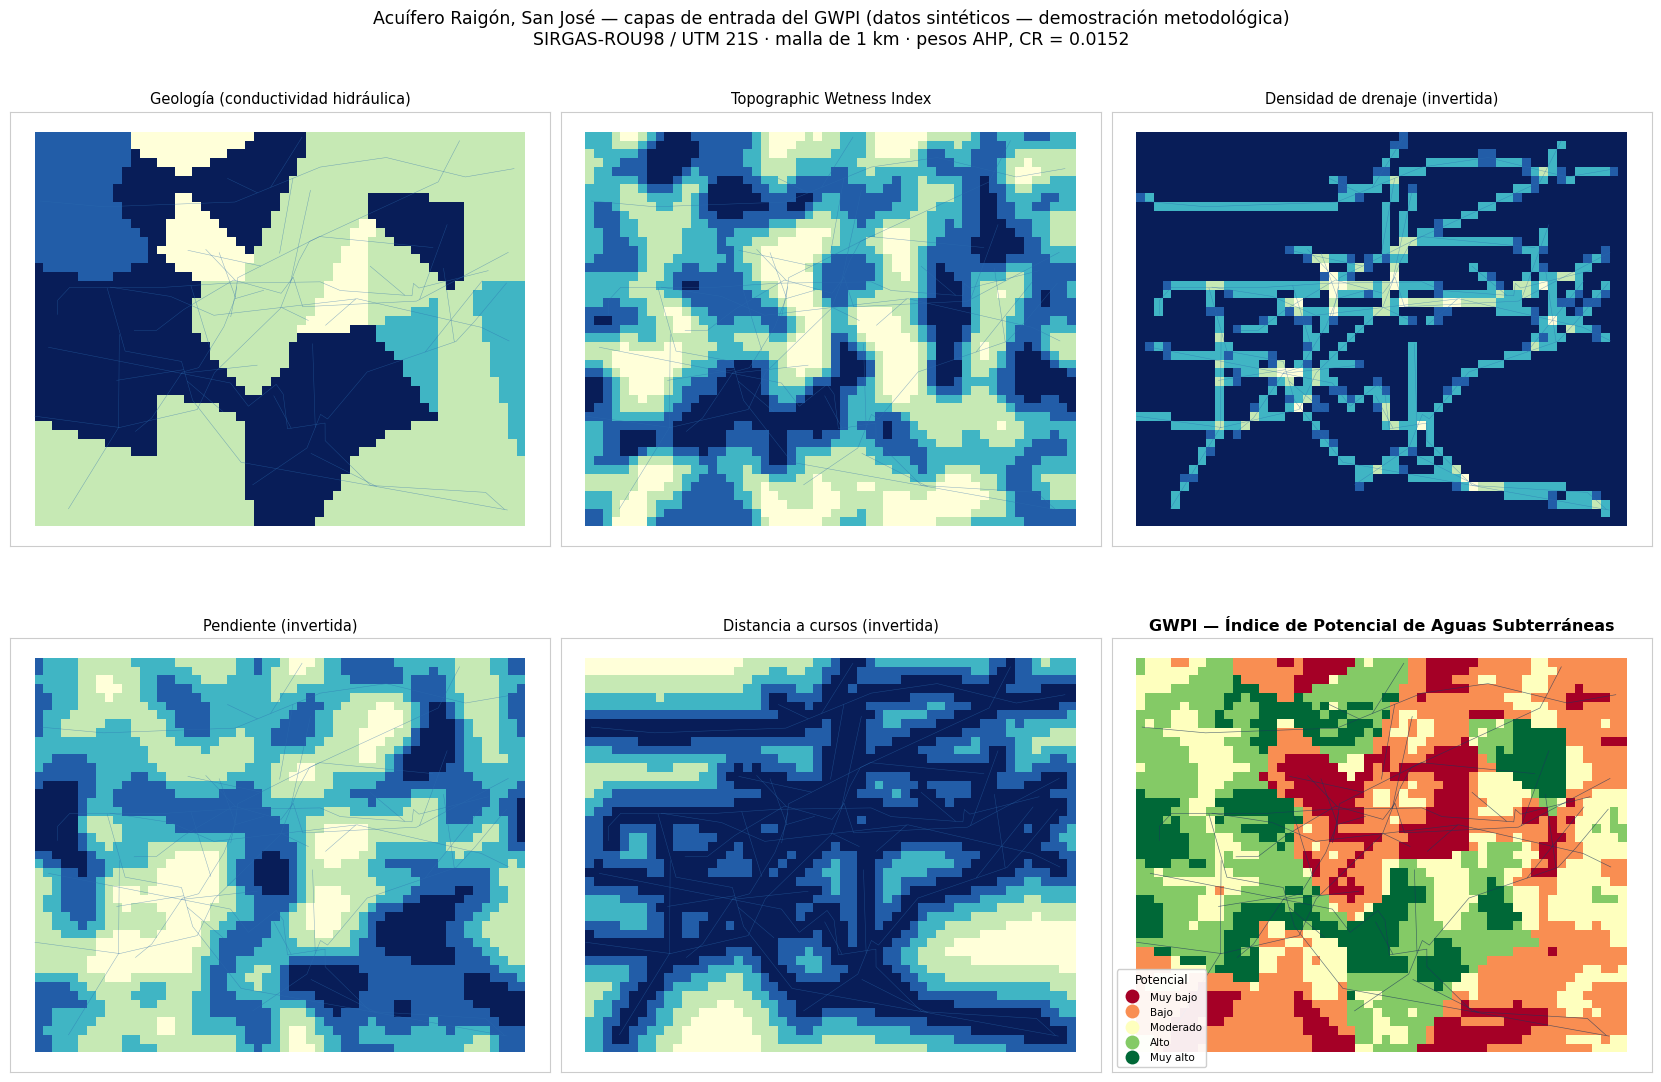

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16.5, 10.5), constrained_layout=True)

paneles = [
    ("r_geologia",      "Geología (conductividad hidráulica)", "YlGnBu"),
    ("r_twi",           "Topographic Wetness Index",           "YlGnBu"),
    ("r_dens_drenaje",  "Densidad de drenaje (invertida)",     "YlGnBu"),
    ("r_pendiente_pct", "Pendiente (invertida)",               "YlGnBu"),
    ("r_dist_cursos_m", "Distancia a cursos (invertida)",      "YlGnBu"),
]

for ax, (col, titulo, cmap) in zip(axes.ravel(), paneles):
    malla.plot(column=col, cmap=cmap, ax=ax, vmin=1, vmax=5,
               edgecolor="none", legend=False)
    drenaje.plot(ax=ax, color="#2b6cb0", linewidth=0.35, alpha=0.55)
    ax.set_title(titulo, fontsize=10.5, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_edgecolor("#cccccc")

ax = axes.ravel()[5]
malla.plot(column="clase_txt", cmap="RdYlGn", ax=ax, legend=True,
           edgecolor="none", legend_kwds={"loc": "lower left", "fontsize": 7.5,
                                          "framealpha": 0.93,
                                          "title": "Potencial", "title_fontsize": 8.5,
                                          "frameon": True})
drenaje.plot(ax=ax, color="#1a365d", linewidth=0.45, alpha=0.7)
ax.set_title("GWPI — Índice de Potencial de Aguas Subterráneas", fontsize=11.5,
             fontweight="bold", pad=6)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_edgecolor("#cccccc")

sub = "datos sintéticos — demostración metodológica" if SINTETICO else "capas del proyecto"
fig.suptitle(f"Acuífero Raigón, San José — capas de entrada del GWPI ({sub})\n"
             f"SIRGAS-ROU98 / UTM 21S · malla de {CELDA_M/1000:g} km · pesos AHP, CR = {CR:.4f}",
             fontsize=12.5, y=1.055)

fig.savefig(DIR_SALIDA / "gwpi_paneles.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

## 13. Exportación

Se escriben tres productos: un **GeoPackage** con la malla calificada y las capas de entrada (un solo
archivo, varias capas, sin el límite de 10 caracteres del nombre de campo del shapefile), un **GeoTIFF**
del GWPI rasterizado a 30 m, y un **JSON** con los parámetros de la corrida para poder rehacerla igual.

In [18]:
gpkg = DIR_SALIDA / "gwpi_raigon.gpkg"
malla.to_file(gpkg, layer="malla_gwpi", driver="GPKG")
geologia.to_file(gpkg, layer="geologia", driver="GPKG")
drenaje.to_file(gpkg, layer="drenaje", driver="GPKG")
aoi.to_file(gpkg, layer="area_estudio", driver="GPKG")
if pozos is not None:
    pozos.to_file(gpkg, layer="pozos", driver="GPKG")

print(f"GeoPackage → {gpkg}")
for capa in gpd.list_layers(gpkg).itertuples():
    print(f"   · {capa.name:15s} {capa.geometry_type}")

GeoPackage → salidas/gwpi_raigon.gpkg
   · malla_gwpi      Polygon
   · geologia        MultiPolygon
   · drenaje         LineString
   · area_estudio    Polygon
   · pozos           Point


In [19]:
# GWPI rasterizado a la resolución de trabajo
gwpi_ras = rasterize(
    ((g, v) for g, v in zip(malla.geometry, malla["gwpi_norm"])),
    out_shape=(alto, ancho), transform=transform, fill=-9999.0, dtype="float32",
)
perfil = dict(driver="GTiff", height=alto, width=ancho, count=1, dtype="float32",
              crs=CRS_PRJ, transform=transform, nodata=-9999.0,
              compress="deflate", tiled=True, blockxsize=256, blockysize=256)

tif = DIR_SALIDA / "gwpi_raigon.tif"
with rasterio.open(tif, "w", **perfil) as dst:
    dst.write(gwpi_ras, 1)
    dst.set_band_description(1, "GWPI normalizado 0-100")

with rasterio.open(tif) as src:
    v = src.read(1, masked=True)
    print(f"GeoTIFF → {tif}")
    print(f"   {src.width} × {src.height} px · {src.crs} · {src.res[0]:.0f} m")
    print(f"   GWPI {v.min():.1f} – {v.max():.1f}  (media {v.mean():.1f})")

GeoTIFF → salidas/gwpi_raigon.tif
   1844 × 1483 px · EPSG:5382 · 30 m
   GWPI 0.0 – 100.0  (media 54.1)


In [20]:
metadatos = {
    "proyecto": "GWPI — Acuífero Raigón, San José, Uruguay",
    "autor": "Juan Nahuel Lamas — GIEx, UTEC",
    "datos": "sintéticos reproducibles" if SINTETICO else "capas del proyecto",
    "semilla": SEMILLA if SINTETICO else None,
    "crs_trabajo": CRS_PRJ,
    "celda_m": CELDA_M,
    "resolucion_raster_m": RES_M,
    "n_celdas": int(len(malla)),
    "criterios": ETIQUETAS,
    "pesos_ahp": {e: round(float(p), 4) for e, p in zip(ETIQUETAS, w)},
    "lambda_max": round(float(lam), 4),
    "razon_consistencia": round(float(CR), 4),
    "rating_geologia": RATING_GEOLOGIA,
    "cortes_jenks": {k: [round(float(b), 4) for b in v] for k, v in cortes.items()},
    "versiones": {"geopandas": gpd.__version__, "rasterio": rasterio.__version__,
                  "mapclassify": mapclassify.__version__, "numpy": np.__version__,
                  "pandas": pd.__version__},
}
ruta_meta = DIR_SALIDA / "parametros_corrida.json"
ruta_meta.write_text(json.dumps(metadatos, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Parámetros → {ruta_meta}\n")
print(json.dumps(metadatos["pesos_ahp"], indent=2, ensure_ascii=False))

Parámetros → salidas/parametros_corrida.json

{
  "Geología": 0.4185,
  "TWI": 0.2625,
  "Densidad drenaje": 0.1599,
  "Pendiente": 0.0973,
  "Distancia a cursos": 0.0618
}


---

## Notas metodológicas y limitaciones

**Sobre la malla.** Una celda de 1 km es un compromiso entre la escala de la cartografía geológica de
entrada (1:100.000) y la resolución del modelo digital de elevación. Afinarla no aporta información: sólo
interpola con más detalle un dato que no lo tiene. El campo `frac_dominante` deja explícitas las celdas
donde la asignación geológica es ambigua, y son las primeras candidatas a revisión en campo.

**Sobre los pesos.** El AHP traslada al resultado el juicio de quien arma la matriz. La razón de
consistencia detecta contradicciones internas, pero no detecta un juicio consistentemente equivocado. Por
eso el paso 11 —el contraste con caudales medidos— no es opcional: es lo único que somete el modelo a un
dato externo.

**Sobre las variables climáticas.** En el proyecto completo, precipitación, evapotranspiración y temperatura
reciben un valor único para toda el área comparado contra el promedio nacional. Es una decisión propia, sin
precedente directo en la bibliografía de AHP-GWP revisada, y está documentada como tal en el README de la
carpeta. La alternativa —interpolar tres estaciones sobre 2.000 km²— habría introducido una estructura
espacial que el dato no respalda.

**Reproducibilidad.** El notebook corre de punta a punta sin datos externos. Con la semilla fija, dos
corridas dan resultados idénticos. Todos los parámetros de la corrida quedan en
`salidas/parametros_corrida.json`.

## Cómo correrlo

```bash
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
jupyter lab 01_preparacion_vectorial_gwpi.ipynb
```

Para usar las capas reales, colocar en `datos/` los archivos `drenaje.gpkg`, `geologia.gpkg`,
`pozos.gpkg`, `pendiente.tif` y `twi.tif`. El notebook los detecta solo.